In [ ]:
# Title: 04_Smith_ElasticNet.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the EN clock on Smith et al

# Set Up

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import LeaveOneOut
from scipy.stats import ttest_ind, mannwhitneyu

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Smith_model_outputs/ElasticNet/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

# Load and format intervention data

In [ ]:
df = pd.read_csv("../../Data_from_Others/Valenzano_Gut_Smith_etal_2017/CountsNormDESeq2_ValenzanoGut_250605.csv")

df.head(5)

,Unnamed: 0,D15.YM.16wk.3,D13.YM.16wk.1,C19.SM.16wk.1,C12.SM.16wk.6,C11.SM.16wk.5,C10.SM.16wk.2,B7.WT.16wk.6,B5.WT.16wk.1,A3.YI.6wk.3,A2.YI.6wk.1,D16.YM.16wk.8,D14.YM.16wk.4,B8.WT.16wk.7,B6.WT.16wk.2,A18.YI.6wk.4,A17.YI.6wk.2
0,cnot8,509.104136,598.130125,496.589632,538.920468,495.189776,503.026874,622.533378,619.841036,557.017265,603.016111,647.082047,520.354131,596.939392,601.223760,584.643093,555.497581
1,LOC107386976,195.809283,113.310365,74.117856,220.718280,245.245791,49.247386,208.413348,68.991002,163.006725,118.279868,162.654504,168.895431,161.612699,150.532646,45.189804,133.069356
2,LOC107379175,203.340409,168.108001,234.397718,313.603890,242.426873,233.338806,176.835568,190.803241,237.524085,454.110206,166.190471,232.353252,215.794991,181.364633,289.026457,435.824468
3,inhbb,237.983590,235.908465,213.088835,313.603890,218.935897,175.883522,140.746677,169.243553,191.882202,409.755256,199.192834,218.685413,142.929150,210.382975,223.124659,424.214390
4,LOC107372844,48.199208,17.646696,25.941249,115.877097,46.042313,32.831591,39.697781,30.183564,68.928558,220.718682,49.503545,22.454306,75.668374,38.086573,165.695949,182.188917


In [ ]:
df.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df.head(5)

,sample,D15.YM.16wk.3,D13.YM.16wk.1,C19.SM.16wk.1,C12.SM.16wk.6,C11.SM.16wk.5,C10.SM.16wk.2,B7.WT.16wk.6,B5.WT.16wk.1,A3.YI.6wk.3,A2.YI.6wk.1,D16.YM.16wk.8,D14.YM.16wk.4,B8.WT.16wk.7,B6.WT.16wk.2,A18.YI.6wk.4,A17.YI.6wk.2
0,cnot8,509.104136,598.130125,496.589632,538.920468,495.189776,503.026874,622.533378,619.841036,557.017265,603.016111,647.082047,520.354131,596.939392,601.223760,584.643093,555.497581
1,LOC107386976,195.809283,113.310365,74.117856,220.718280,245.245791,49.247386,208.413348,68.991002,163.006725,118.279868,162.654504,168.895431,161.612699,150.532646,45.189804,133.069356
2,LOC107379175,203.340409,168.108001,234.397718,313.603890,242.426873,233.338806,176.835568,190.803241,237.524085,454.110206,166.190471,232.353252,215.794991,181.364633,289.026457,435.824468
3,inhbb,237.983590,235.908465,213.088835,313.603890,218.935897,175.883522,140.746677,169.243553,191.882202,409.755256,199.192834,218.685413,142.929150,210.382975,223.124659,424.214390
4,LOC107372844,48.199208,17.646696,25.941249,115.877097,46.042313,32.831591,39.697781,30.183564,68.928558,220.718682,49.503545,22.454306,75.668374,38.086573,165.695949,182.188917


In [ ]:
df.set_index("sample", inplace=True)

df.head(5)

,D15.YM.16wk.3,D13.YM.16wk.1,C19.SM.16wk.1,C12.SM.16wk.6,C11.SM.16wk.5,C10.SM.16wk.2,B7.WT.16wk.6,B5.WT.16wk.1,A3.YI.6wk.3,A2.YI.6wk.1,D16.YM.16wk.8,D14.YM.16wk.4,B8.WT.16wk.7,B6.WT.16wk.2,A18.YI.6wk.4,A17.YI.6wk.2
sample,,,,,,,,,,,,,,,,
cnot8,509.104136,598.130125,496.589632,538.920468,495.189776,503.026874,622.533378,619.841036,557.017265,603.016111,647.082047,520.354131,596.939392,601.223760,584.643093,555.497581
LOC107386976,195.809283,113.310365,74.117856,220.718280,245.245791,49.247386,208.413348,68.991002,163.006725,118.279868,162.654504,168.895431,161.612699,150.532646,45.189804,133.069356
LOC107379175,203.340409,168.108001,234.397718,313.603890,242.426873,233.338806,176.835568,190.803241,237.524085,454.110206,166.190471,232.353252,215.794991,181.364633,289.026457,435.824468
inhbb,237.983590,235.908465,213.088835,313.603890,218.935897,175.883522,140.746677,169.243553,191.882202,409.755256,199.192834,218.685413,142.929150,210.382975,223.124659,424.214390
LOC107372844,48.199208,17.646696,25.941249,115.877097,46.042313,32.831591,39.697781,30.183564,68.928558,220.718682,49.503545,22.454306,75.668374,38.086573,165.695949,182.188917


In [ ]:
df = df.T

df.head(5)

sample,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,tox4,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,197.315508,1748.727520,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,170.894321,1429.382394,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967
C19.SM.16wk.1,496.589632,74.117856,234.397718,213.088835,25.941249,100.059105,264.044860,20286.983528,42.617767,3952.334645,...,201.044683,1360.062649,0.000000,226.059459,173.250487,1.852946,36.132455,341.868609,242.735977,142.676872
C12.SM.16wk.6,538.920468,220.718280,313.603890,313.603890,115.877097,233.593513,194.048155,13372.768817,28.509445,3864.409227,...,125.993352,1526.634773,1.839319,282.335467,223.477259,9.196595,20.232509,411.087797,223.477259,101.162545
C11.SM.16wk.5,495.189776,245.245791,242.426873,218.935897,46.042313,167.255750,162.557555,14011.897427,15.034225,10882.899410,...,150.342247,1445.164850,1.879278,293.167382,203.901673,3.758556,27.249532,410.622262,191.686365,109.937768


In [ ]:
df_metadata = pd.read_csv("../../Data_from_Others/Valenzano_Gut_Smith_etal_2017/ExperimentDesign_ValenzanoGut_update.csv")

df_metadata.head(5)

,Sample.Name,Run,AGE,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,sex,SRA.Study,strain,tissue,treatment,file,lib
0,D15.YM.16wk.3,SRR5344336,16 weeks,RNA-Seq,202,6181107686,Dario Riccardo Valenzano,PRJNA379208,SAMN06603517,Model organism or animal,...,2017-08-24T00:00:00Z,2017-03-15T04:51:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.3,SRR5344336.featureCounts,SRR5344336
1,D13.YM.16wk.1,SRR5344338,16 weeks,RNA-Seq,202,6073706508,Dario Riccardo Valenzano,PRJNA379208,SAMN06603515,Model organism or animal,...,2017-08-24T00:00:00Z,2017-03-15T04:46:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.1,SRR5344338.featureCounts,SRR5344338
2,C19.SM.16wk.1,SRR5344339,16 weeks,RNA-Seq,202,5771959312,Dario Riccardo Valenzano,PRJNA379208,SAMN06603511,Model organism or animal,...,2017-08-24T00:00:00Z,2017-03-15T04:44:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.1,SRR5344339.featureCounts,SRR5344339
3,C12.SM.16wk.6,SRR5344340,16 weeks,RNA-Seq,202,5878546430,Dario Riccardo Valenzano,PRJNA379208,SAMN06603514,Model organism or animal,...,2017-08-24T00:00:00Z,2017-03-15T04:49:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.6,SRR5344340.featureCounts,SRR5344340
4,C11.SM.16wk.5,SRR5344341,16 weeks,RNA-Seq,202,6215614538,Dario Riccardo Valenzano,PRJNA379208,SAMN06603513,Model organism or animal,...,2017-08-24T00:00:00Z,2017-03-15T04:52:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.5,SRR5344341.featureCounts,SRR5344341


In [ ]:
df_metadata.set_index("Sample.Name", inplace=True)

df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,ReleaseDate,create_date,version,sex,SRA.Study,strain,tissue,treatment,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
D15.YM.16wk.3,SRR5344336,16 weeks,RNA-Seq,202,6181107686,Dario Riccardo Valenzano,PRJNA379208,SAMN06603517,Model organism or animal,4320625985,...,2017-08-24T00:00:00Z,2017-03-15T04:51:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.3,SRR5344336.featureCounts,SRR5344336
D13.YM.16wk.1,SRR5344338,16 weeks,RNA-Seq,202,6073706508,Dario Riccardo Valenzano,PRJNA379208,SAMN06603515,Model organism or animal,4262337437,...,2017-08-24T00:00:00Z,2017-03-15T04:46:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.1,SRR5344338.featureCounts,SRR5344338
C19.SM.16wk.1,SRR5344339,16 weeks,RNA-Seq,202,5771959312,Dario Riccardo Valenzano,PRJNA379208,SAMN06603511,Model organism or animal,4015705208,...,2017-08-24T00:00:00Z,2017-03-15T04:44:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.1,SRR5344339.featureCounts,SRR5344339
C12.SM.16wk.6,SRR5344340,16 weeks,RNA-Seq,202,5878546430,Dario Riccardo Valenzano,PRJNA379208,SAMN06603514,Model organism or animal,4138065832,...,2017-08-24T00:00:00Z,2017-03-15T04:49:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.6,SRR5344340.featureCounts,SRR5344340
C11.SM.16wk.5,SRR5344341,16 weeks,RNA-Seq,202,6215614538,Dario Riccardo Valenzano,PRJNA379208,SAMN06603513,Model organism or animal,4368564776,...,2017-08-24T00:00:00Z,2017-03-15T04:52:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.5,SRR5344341.featureCounts,SRR5344341


In [ ]:
df_metadata["AGE"].value_counts()

AGE
16 weeks    12
6 weeks      4
Name: count, dtype: int64

In [ ]:
df_metadata.columns

Index(['Run', 'AGE', 'Assay.Type', 'AvgSpotLen', 'Bases',
       'BIOMATERIAL_PROVIDER', 'BioProject', 'BioSample', 'BioSampleModel',
       'Bytes', 'Center.Name', 'Consent', 'DATASTORE.filetype',
       'DATASTORE.provider', 'DATASTORE.region', 'Experiment', 'Instrument',
       'Library.Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource',
       'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'sex',
       'SRA.Study', 'strain', 'tissue', 'treatment', 'file', 'lib'],
      dtype='object')

In [ ]:
df_metadata["tissue"].value_counts()

tissue
Intestine    16
Name: count, dtype: int64

In [ ]:
df_metadata["sex"].value_counts()

sex
male    16
Name: count, dtype: int64

In [ ]:
df_metadata.index.dtype

dtype('O')

In [ ]:
df_metadata.index.tolist()

['D15.YM.16wk.3',
 'D13.YM.16wk.1',
 'C19.SM.16wk.1',
 'C12.SM.16wk.6',
 'C11.SM.16wk.5',
 'C10.SM.16wk.2',
 'B7.WT.16wk.6',
 'B5.WT.16wk.1',
 'A3.YI.6wk.3',
 'A2.YI.6wk.1',
 'D16.YM.16wk.8',
 'D14.YM.16wk.4',
 'B8.WT.16wk.7',
 'B6.WT.16wk.2',
 'A18.YI.6wk.4',
 'A17.YI.6wk.2']

In [ ]:
# Map weeks to days
age_to_days = {'16 weeks': 112, '6 weeks': 42}

# Create the 'days' column
df_metadata['days'] = df_metadata['AGE'].map(age_to_days)

In [ ]:
df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,create_date,version,sex,SRA.Study,strain,tissue,treatment,file,lib,days
Sample.Name,,,,,,,,,,,,,,,,,,,,,
D15.YM.16wk.3,SRR5344336,16 weeks,RNA-Seq,202,6181107686,Dario Riccardo Valenzano,PRJNA379208,SAMN06603517,Model organism or animal,4320625985,...,2017-03-15T04:51:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.3,SRR5344336.featureCounts,SRR5344336,112
D13.YM.16wk.1,SRR5344338,16 weeks,RNA-Seq,202,6073706508,Dario Riccardo Valenzano,PRJNA379208,SAMN06603515,Model organism or animal,4262337437,...,2017-03-15T04:46:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.1,SRR5344338.featureCounts,SRR5344338,112
C19.SM.16wk.1,SRR5344339,16 weeks,RNA-Seq,202,5771959312,Dario Riccardo Valenzano,PRJNA379208,SAMN06603511,Model organism or animal,4015705208,...,2017-03-15T04:44:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.1,SRR5344339.featureCounts,SRR5344339,112
C12.SM.16wk.6,SRR5344340,16 weeks,RNA-Seq,202,5878546430,Dario Riccardo Valenzano,PRJNA379208,SAMN06603514,Model organism or animal,4138065832,...,2017-03-15T04:49:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.6,SRR5344340.featureCounts,SRR5344340,112
C11.SM.16wk.5,SRR5344341,16 weeks,RNA-Seq,202,6215614538,Dario Riccardo Valenzano,PRJNA379208,SAMN06603513,Model organism or animal,4368564776,...,2017-03-15T04:52:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.5,SRR5344341.featureCounts,SRR5344341,112


In [ ]:
df_metadata = df_metadata.loc[df.index.tolist(), ]

df_metadata.head(5)

,Run,AGE,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,create_date,version,sex,SRA.Study,strain,tissue,treatment,file,lib,days
Sample.Name,,,,,,,,,,,,,,,,,,,,,
D15.YM.16wk.3,SRR5344336,16 weeks,RNA-Seq,202,6181107686,Dario Riccardo Valenzano,PRJNA379208,SAMN06603517,Model organism or animal,4320625985,...,2017-03-15T04:51:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.3,SRR5344336.featureCounts,SRR5344336,112
D13.YM.16wk.1,SRR5344338,16 weeks,RNA-Seq,202,6073706508,Dario Riccardo Valenzano,PRJNA379208,SAMN06603515,Model organism or animal,4262337437,...,2017-03-15T04:46:00Z,1,male,SRP101912,GRZ,Intestine,YM.16wk.1,SRR5344338.featureCounts,SRR5344338,112
C19.SM.16wk.1,SRR5344339,16 weeks,RNA-Seq,202,5771959312,Dario Riccardo Valenzano,PRJNA379208,SAMN06603511,Model organism or animal,4015705208,...,2017-03-15T04:44:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.1,SRR5344339.featureCounts,SRR5344339,112
C12.SM.16wk.6,SRR5344340,16 weeks,RNA-Seq,202,5878546430,Dario Riccardo Valenzano,PRJNA379208,SAMN06603514,Model organism or animal,4138065832,...,2017-03-15T04:49:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.6,SRR5344340.featureCounts,SRR5344340,112
C11.SM.16wk.5,SRR5344341,16 weeks,RNA-Seq,202,6215614538,Dario Riccardo Valenzano,PRJNA379208,SAMN06603513,Model organism or animal,4368564776,...,2017-03-15T04:52:00Z,1,male,SRP101912,GRZ,Intestine,SM.16wk.5,SRR5344341.featureCounts,SRR5344341,112


In [ ]:
smith_age = df.copy()

smith_age["age"] = df_metadata['days'].tolist()

smith_age.head(5)

sample,cnot8,LOC107386976,LOC107379175,inhbb,LOC107372844,LOC107391735,dhdds,LOC107384934,LOC107375999,LOC107396709,...,ndufs5,slc24a1,homer2,porcn,LOC107373816,barx2,fbxl6,rtca,LOC107388120,age
D15.YM.16wk.3,509.104136,195.809283,203.340409,237.983590,48.199208,280.157897,192.796833,15750.597485,55.730334,10766.498119,...,1748.727520,3.012451,280.157897,224.427563,7.531126,3.012451,387.099890,176.228355,90.373515,112
D13.YM.16wk.1,598.130125,113.310365,168.108001,235.908465,17.646696,65.014144,249.840068,19168.955965,19.504243,5729.603631,...,1429.382394,1.857547,230.335824,202.472620,1.857547,6.501414,333.429681,177.395736,127.241967,112
C19.SM.16wk.1,496.589632,74.117856,234.397718,213.088835,25.941249,100.059105,264.044860,20286.983528,42.617767,3952.334645,...,1360.062649,0.000000,226.059459,173.250487,1.852946,36.132455,341.868609,242.735977,142.676872,112
C12.SM.16wk.6,538.920468,220.718280,313.603890,313.603890,115.877097,233.593513,194.048155,13372.768817,28.509445,3864.409227,...,1526.634773,1.839319,282.335467,223.477259,9.196595,20.232509,411.087797,223.477259,101.162545,112
C11.SM.16wk.5,495.189776,245.245791,242.426873,218.935897,46.042313,167.255750,162.557555,14011.897427,15.034225,10882.899410,...,1445.164850,1.879278,293.167382,203.901673,3.758556,27.249532,410.622262,191.686365,109.937768,112


In [ ]:
smith_age["age"].value_counts()

age
112    12
42      4
Name: count, dtype: int64

# Load and format Atlas data

In [ ]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

df_norm.head(5)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
a1cf,23876.707871,36.845369,4821.965545,4.382338,7011.583272,8.609836,7322.278018,6.381242,2.350903,26.477799,...,13.252489,114040.165660,4607.517959,28345.868500,3779.000332,109305.285390,2773.097943,23.137624,6880.253530,11.240853
aaas,687.004459,407.384647,907.596706,451.380822,766.674115,486.229181,732.665214,390.531984,453.724234,505.640544,...,494.419778,772.337090,213.064414,986.528729,458.630232,521.430751,298.548839,460.251117,1212.101691,538.062177
aacs,2181.018965,349.683408,218.510659,1198.256441,222.103168,1020.945335,225.267215,1030.570512,134.001458,194.739939,...,1082.626401,16360.632638,432.047285,9800.884823,519.718275,961.296916,358.659344,703.508841,335.429875,923.998139
aadat,576.907591,374.015256,554.051370,303.633424,627.278822,358.441083,592.693352,342.672672,712.323538,536.388955,...,995.975512,764.886893,218.982870,357.140964,277.245734,766.124512,238.438335,929.257011,684.872487,349.215842
aaed1,221.294706,493.588906,191.503723,289.860362,272.285474,187.603803,260.260180,241.849055,481.935067,640.591905,...,127.427778,42.217783,84.337997,43.910774,223.676220,61.173440,134.246793,99.429250,218.073209,198.588408


In [ ]:
df_norm = df_norm.T

In [ ]:
df_metadata_atlas = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata_atlas.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata_atlas.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata_atlas.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata_atlas.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata_atlas[['sex', 'tissue', 'age_days']]], axis=1)

combined_df.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162


In [ ]:
gut_df = combined_df.loc[combined_df.iloc[:,-2] == "Gut"]

gut_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,F,Gut,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,F,Gut,75
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134


In [ ]:
gut_df_age = gut_df.iloc[:,:-3]

gut_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,913.804009,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.748070,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,804.677628,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,770.127782,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,816.301700,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254


In [ ]:
gut_df_age["age"] = gut_df["age_days"].tolist()

## Sex Combined

In [ ]:
gut_atlas_plus_smith = pd.concat([gut_df_age, smith_age], axis=0)

gut_atlas_plus_smith.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,178.356927,1117.483215,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,155
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133
A3_1,25474.794219,394.841817,2380.296399,618.502214,223.660397,730.957162,1441.922333,1626.848248,689.723681,502.298768,...,153.688429,1270.740912,252.398883,1593.111763,31.237486,541.033250,3708.514285,2226.607970,314.873854,134
A4_1,21094.343422,503.698033,2804.802732,581.903780,319.450595,775.429867,1249.966435,1181.039336,534.185019,514.302202,...,163.039100,1112.112236,172.317748,1569.417030,86.158874,393.679779,3952.704039,1851.753033,279.684961,75
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,134


In [ ]:
gut_atlas_smith_data = gut_atlas_plus_smith.values

In [ ]:
X, y = gut_atlas_smith_data[:,:-1], gut_atlas_smith_data[:,-1]

In [ ]:
# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Set a seed for reproducibility
seed = 42

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1, return_train_score=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

## Best parameters

#### alpha = 0.1, l1_ratio = 0.8



In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    #model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    model = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 9.908
Pearson correlation: 0.950
R-squared: 0.894
Average number of non-zero coefficients: 178.32


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': gut_atlas_plus_smith["age"].tolist(),
}, index=gut_atlas_plus_smith.index.tolist())

df_prediction.head(10)

,y_pred,age
A1_1,127.954558,155
A2_1,152.297172,133
A3_1,125.777702,134
A4_1,82.500823,75
B1_1,130.769936,134
B2_1,109.553286,103
B3_1,48.623359,52
B4_1,56.642635,47
C1_1,58.276122,52
C2_1,95.134908,133


In [ ]:
df_prediction_smith = df_prediction.loc[smith_age.index.tolist(), ]

df_prediction_smith.head(5)

,y_pred,age
D15.YM.16wk.3,94.389720,112
D13.YM.16wk.1,97.477900,112
C19.SM.16wk.1,106.708814,112
C12.SM.16wk.6,99.180736,112
C11.SM.16wk.5,116.248518,112


In [ ]:
df_prediction_smith["treatment"] = df_metadata["treatment"].tolist()

df_prediction_smith.head(5)

,y_pred,age,treatment
D15.YM.16wk.3,94.389720,112,YM.16wk.3
D13.YM.16wk.1,97.477900,112,YM.16wk.1
C19.SM.16wk.1,106.708814,112,SM.16wk.1
C12.SM.16wk.6,99.180736,112,SM.16wk.6
C11.SM.16wk.5,116.248518,112,SM.16wk.5


In [ ]:
# Extract the genotype from the treatment column
df_prediction_smith['genotype'] = df_prediction_smith['treatment'].str.extract(r'^(WT|YI|YM|SM)')

print(df_prediction_smith)

                   y_pred  age  treatment genotype
D15.YM.16wk.3   94.389720  112  YM.16wk.3       YM
D13.YM.16wk.1   97.477900  112  YM.16wk.1       YM
C19.SM.16wk.1  106.708814  112  SM.16wk.1       SM
C12.SM.16wk.6   99.180736  112  SM.16wk.6       SM
C11.SM.16wk.5  116.248518  112  SM.16wk.5       SM
C10.SM.16wk.2  109.000205  112  SM.16wk.2       SM
B7.WT.16wk.6   113.562527  112  WT.16wk.6       WT
B5.WT.16wk.1   110.837729  112  WT.16wk.1       WT
A3.YI.6wk.3     55.403597   42   YI.6wk.3       YI
A2.YI.6wk.1     50.917388   42   YI.6wk.1       YI
D16.YM.16wk.8  117.829118  112  YM.16wk.8       YM
D14.YM.16wk.4  113.258738  112  YM.16wk.4       YM
B8.WT.16wk.7   107.049920  112  WT.16wk.7       WT
B6.WT.16wk.2   116.244517  112  WT.16wk.2       WT
A18.YI.6wk.4    49.508706   42   YI.6wk.4       YI
A17.YI.6wk.2    44.841027   42   YI.6wk.2       YI


In [ ]:
df_prediction_smith.to_csv("./df_prediction_smith_sex_combined.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

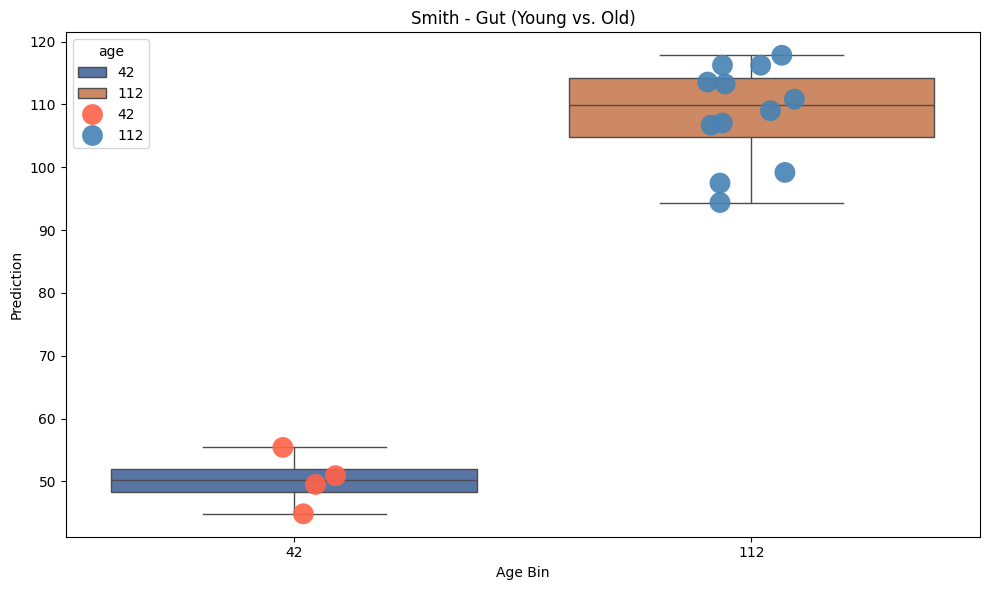

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_smith, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_smith,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Smith - Gut (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_7w = df_prediction_smith[df_prediction_smith['age'] == 42]['y_pred']
group_18w = df_prediction_smith[df_prediction_smith['age'] == 112]['y_pred']

print("Group 7w size:", len(group_7w))
print("Group 18w size:", len(group_18w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_7w, group_18w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_7w, group_18w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 7w size: 4
Group 18w size: 12
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0011


In [ ]:
df_prediction_smith_young = df_prediction_smith[df_prediction_smith["age"] == 42]

df_prediction_smith_young.head(5)

,y_pred,age,treatment,genotype
A3.YI.6wk.3,55.403597,42,YI.6wk.3,YI
A2.YI.6wk.1,50.917388,42,YI.6wk.1,YI
A18.YI.6wk.4,49.508706,42,YI.6wk.4,YI
A17.YI.6wk.2,44.841027,42,YI.6wk.2,YI


In [ ]:
df_prediction_smith_young

,y_pred,age,treatment,genotype
A3.YI.6wk.3,55.403597,42,YI.6wk.3,YI
A2.YI.6wk.1,50.917388,42,YI.6wk.1,YI
A18.YI.6wk.4,49.508706,42,YI.6wk.4,YI
A17.YI.6wk.2,44.841027,42,YI.6wk.2,YI


In [ ]:
df_prediction_smith_old = df_prediction_smith[df_prediction_smith["age"] == 112]

df_prediction_smith_old.head(5)

,y_pred,age,treatment,genotype
D15.YM.16wk.3,94.389720,112,YM.16wk.3,YM
D13.YM.16wk.1,97.477900,112,YM.16wk.1,YM
C19.SM.16wk.1,106.708814,112,SM.16wk.1,SM
C12.SM.16wk.6,99.180736,112,SM.16wk.6,SM
C11.SM.16wk.5,116.248518,112,SM.16wk.5,SM


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

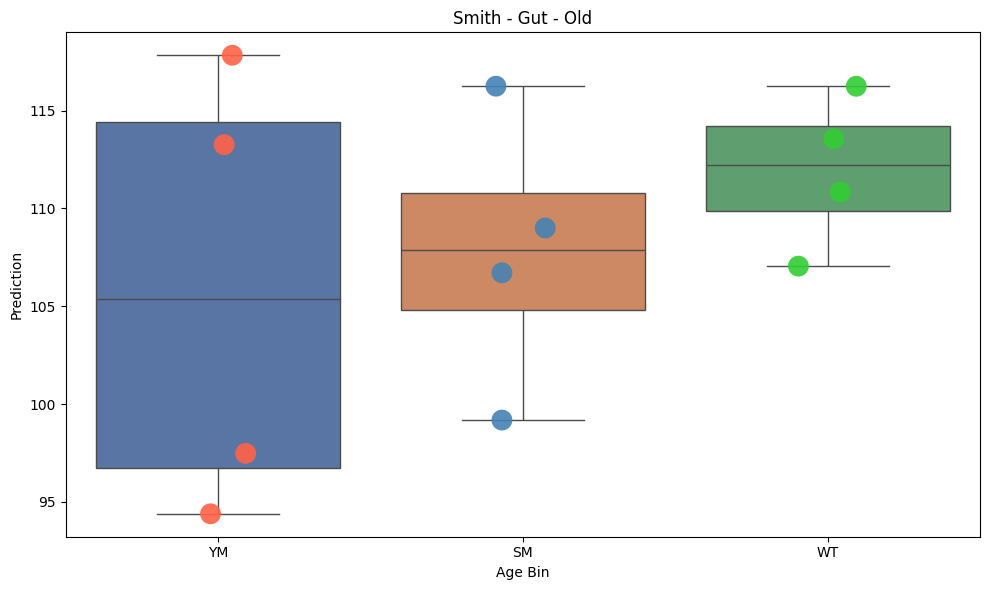

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_smith_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_smith_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Smith - Gut - Old')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

### Male

In [ ]:
gut_df_male = gut_df[gut_df["sex"] == "M"]

gut_df_male.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,M,Gut,133
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,M,Gut,134
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922,M,Gut,103


In [ ]:
gut_df_male_age = gut_df_male.iloc[:,:-3]

gut_df_male_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,1070.748070,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,816.301700,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,797.407802,153.243336,972.349310,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922
B4_1,21628.605092,513.719306,1576.939361,545.667024,249.192200,802.526676,1247.238911,1469.595028,609.562460,591.671738,...,764.189415,116.289694,1166.730662,154.626955,1594.830083,44.726805,522.664667,4895.668308,1828.687379,385.928434
C2_1,14676.825139,518.280406,1492.063592,346.006919,105.116026,617.556653,1084.738991,1257.012478,586.897812,543.099468,...,819.029036,68.617406,858.447546,134.314922,1721.274927,21.899172,452.582890,3622.123065,1556.301164,243.810783


In [ ]:
gut_df_male_age["age"] = gut_df_male["age_days"].tolist()

In [ ]:
gut_atlas_plus_smith_male = pd.concat([gut_df_male_age, smith_age], axis=0)

gut_atlas_plus_smith_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A2_1,23741.305346,614.790132,4013.251397,576.451327,286.171799,729.806549,1381.566243,1759.477327,503.881445,453.219451,...,116.385660,839.345993,214.971160,1263.811341,50.661993,412.142160,4515.763598,2272.943473,276.587097,133
B1_1,26292.108219,472.266501,1996.967953,731.856697,308.067883,889.800129,1341.737278,1681.081088,476.957890,440.990574,...,129.795098,1013.340042,148.560654,1469.968579,10.946575,688.070399,3907.927106,1620.093030,320.578254,134
B2_1,22277.241433,401.416172,988.622938,595.343580,231.899208,809.613023,1475.475661,1647.704897,394.635494,561.440187,...,153.243336,972.349310,233.255343,1122.880374,21.698171,565.508594,3923.300631,1360.204125,259.021922,103
B4_1,21628.605092,513.719306,1576.939361,545.667024,249.192200,802.526676,1247.238911,1469.595028,609.562460,591.671738,...,116.289694,1166.730662,154.626955,1594.830083,44.726805,522.664667,4895.668308,1828.687379,385.928434,47
C2_1,14676.825139,518.280406,1492.063592,346.006919,105.116026,617.556653,1084.738991,1257.012478,586.897812,543.099468,...,68.617406,858.447546,134.314922,1721.274927,21.899172,452.582890,3622.123065,1556.301164,243.810783,133


In [ ]:
gut_atlas_smith_male_data = gut_atlas_plus_smith_male.values

In [ ]:
X, y = gut_atlas_smith_male_data[:,:-1], gut_atlas_smith_male_data[:,-1]

In [ ]:
# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Set a seed for reproducibility
seed = 42

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1, return_train_score=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Best parameters

### alpha = 0.1, l1_ratio = 0.5

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 13.929
Pearson correlation: 0.911
R-squared: 0.807
Average number of non-zero coefficients: 447.79


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': gut_atlas_plus_smith_male["age"].tolist(),
}, index=gut_atlas_plus_smith_male.index.tolist())

df_prediction.head(10)

,y_pred,age
A2_1,150.441300,133
B1_1,129.991528,134
B2_1,102.431026,103
B4_1,68.523123,47
C2_1,99.143612,133
C4_1,121.336979,133
D1_1,65.140641,52
D2_1,142.454295,161
D3_1,132.184327,162
E1_1,108.232403,78


In [ ]:
df_prediction_smith = df_prediction.loc[smith_age.index.tolist(), ]

df_prediction_smith.head(5)

,y_pred,age
D15.YM.16wk.3,83.540156,112
D13.YM.16wk.1,102.502557,112
C19.SM.16wk.1,105.503430,112
C12.SM.16wk.6,93.585863,112
C11.SM.16wk.5,116.107318,112


In [ ]:
df_metadata.columns

Index(['Run', 'AGE', 'Assay.Type', 'AvgSpotLen', 'Bases',
       'BIOMATERIAL_PROVIDER', 'BioProject', 'BioSample', 'BioSampleModel',
       'Bytes', 'Center.Name', 'Consent', 'DATASTORE.filetype',
       'DATASTORE.provider', 'DATASTORE.region', 'Experiment', 'Instrument',
       'Library.Name', 'LibraryLayout', 'LibrarySelection', 'LibrarySource',
       'Organism', 'Platform', 'ReleaseDate', 'create_date', 'version', 'sex',
       'SRA.Study', 'strain', 'tissue', 'treatment', 'file', 'lib', 'days'],
      dtype='object')

In [ ]:
#df_prediction_smith["age"] = df_prediction["age"].tolist()
df_prediction_smith["treatment"] = df_metadata["treatment"].tolist()

In [ ]:
# Extract the genotype from the treatment column
df_prediction_smith['genotype'] = df_prediction_smith['treatment'].str.extract(r'^(WT|YI|YM|SM)')

print(df_prediction_smith)

                   y_pred  age  treatment genotype
D15.YM.16wk.3   83.540156  112  YM.16wk.3       YM
D13.YM.16wk.1  102.502557  112  YM.16wk.1       YM
C19.SM.16wk.1  105.503430  112  SM.16wk.1       SM
C12.SM.16wk.6   93.585863  112  SM.16wk.6       SM
C11.SM.16wk.5  116.107318  112  SM.16wk.5       SM
C10.SM.16wk.2  105.858406  112  SM.16wk.2       SM
B7.WT.16wk.6   115.460038  112  WT.16wk.6       WT
B5.WT.16wk.1   124.968741  112  WT.16wk.1       WT
A3.YI.6wk.3     52.788802   42   YI.6wk.3       YI
A2.YI.6wk.1     53.194560   42   YI.6wk.1       YI
D16.YM.16wk.8  110.574973  112  YM.16wk.8       YM
D14.YM.16wk.4  121.632448  112  YM.16wk.4       YM
B8.WT.16wk.7   112.103760  112  WT.16wk.7       WT
B6.WT.16wk.2   121.448072  112  WT.16wk.2       WT
A18.YI.6wk.4    43.482352   42   YI.6wk.4       YI
A17.YI.6wk.2    43.988673   42   YI.6wk.2       YI


In [ ]:
df_prediction_smith.to_csv("./df_prediction_smith_male.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

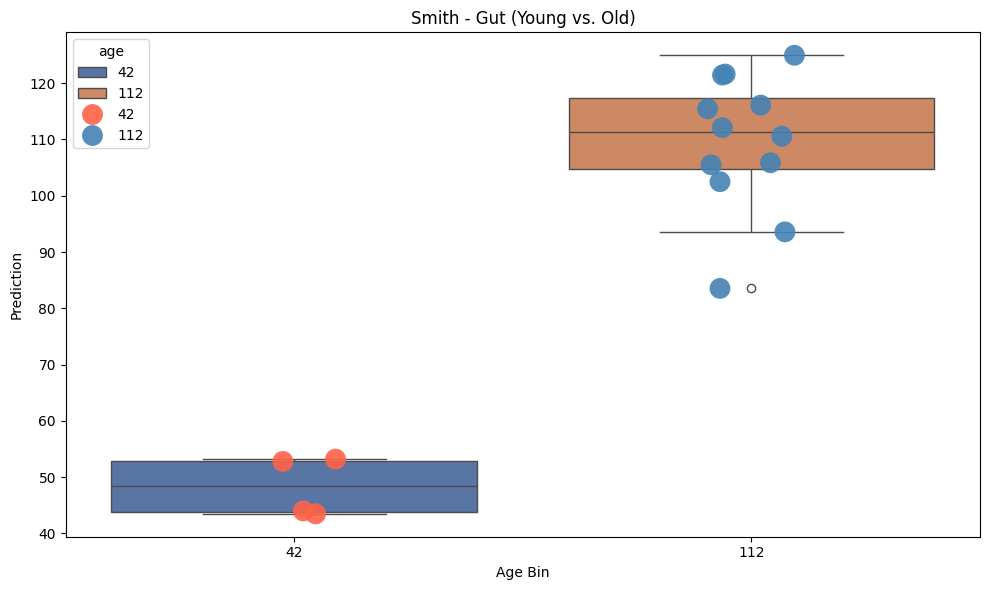

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_smith, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_smith,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Smith - Gut (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_7w = df_prediction_smith[df_prediction_smith['age'] == 42]['y_pred']
group_18w = df_prediction_smith[df_prediction_smith['age'] == 112]['y_pred']

print("Group 7w size:", len(group_7w))
print("Group 18w size:", len(group_18w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_7w, group_18w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_7w, group_18w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 7w size: 4
Group 18w size: 12
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0011


In [ ]:
df_prediction_smith_young = df_prediction_smith[df_prediction_smith["age"] == 42]

df_prediction_smith_young.head(5)

,y_pred,age,treatment,genotype
A3.YI.6wk.3,52.788802,42,YI.6wk.3,YI
A2.YI.6wk.1,53.194560,42,YI.6wk.1,YI
A18.YI.6wk.4,43.482352,42,YI.6wk.4,YI
A17.YI.6wk.2,43.988673,42,YI.6wk.2,YI


In [ ]:
df_prediction_smith_old = df_prediction_smith[df_prediction_smith["age"] == 112]

df_prediction_smith_old.head(5)

,y_pred,age,treatment,genotype
D15.YM.16wk.3,83.540156,112,YM.16wk.3,YM
D13.YM.16wk.1,102.502557,112,YM.16wk.1,YM
C19.SM.16wk.1,105.503430,112,SM.16wk.1,SM
C12.SM.16wk.6,93.585863,112,SM.16wk.6,SM
C11.SM.16wk.5,116.107318,112,SM.16wk.5,SM


/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

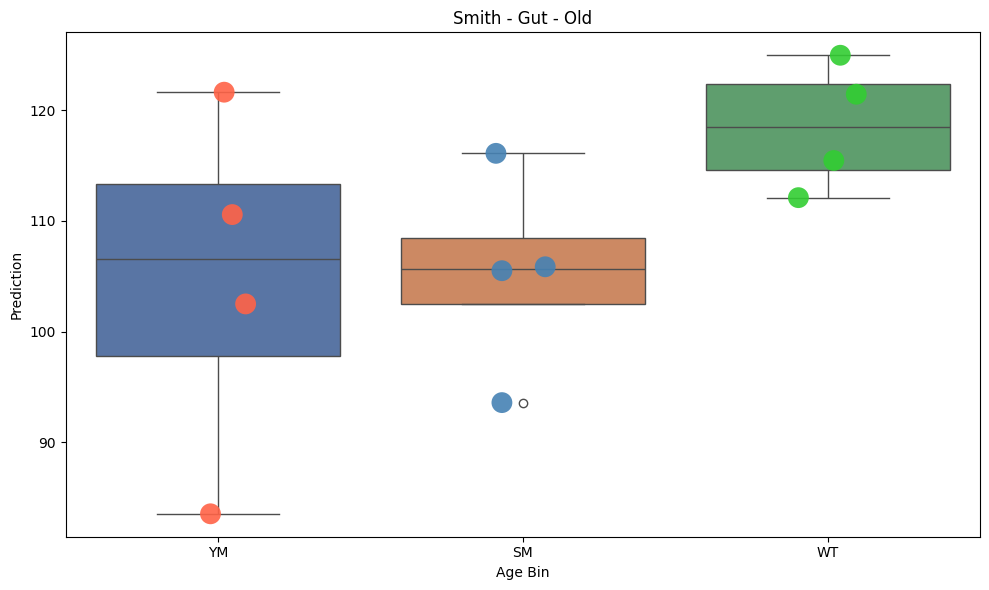

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='genotype', y='y_pred', hue='genotype', data=df_prediction_smith_old, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='genotype',
    y='y_pred',
    hue='genotype',
    data=df_prediction_smith_old,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Smith - Gut - Old')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()